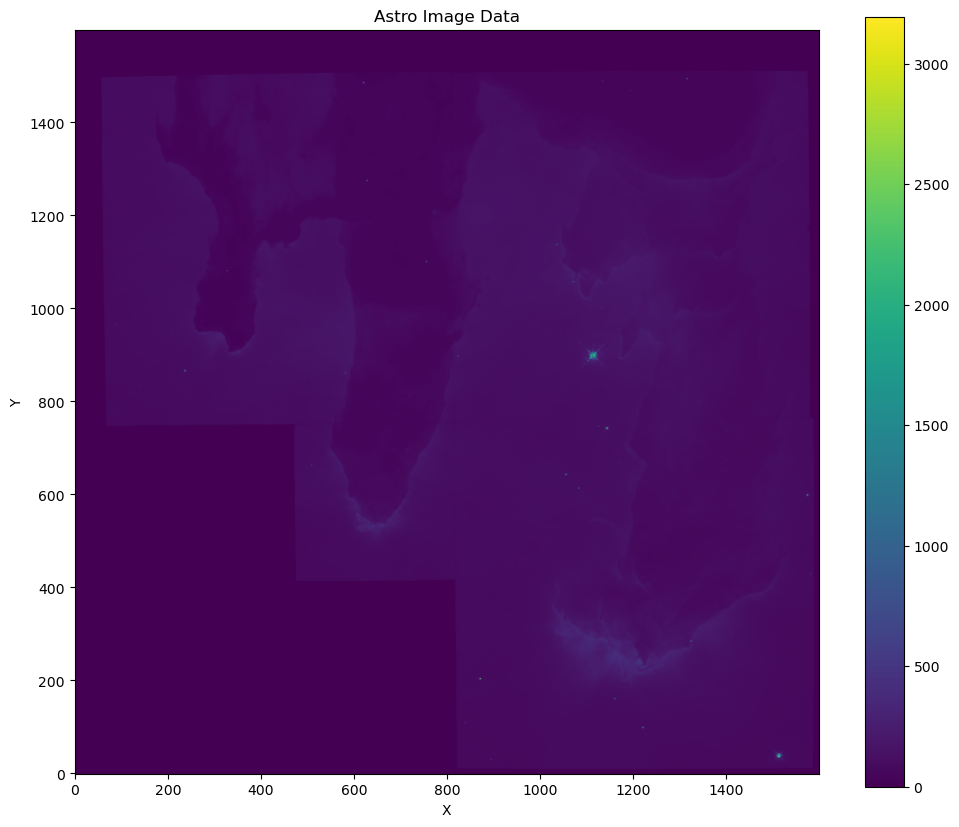

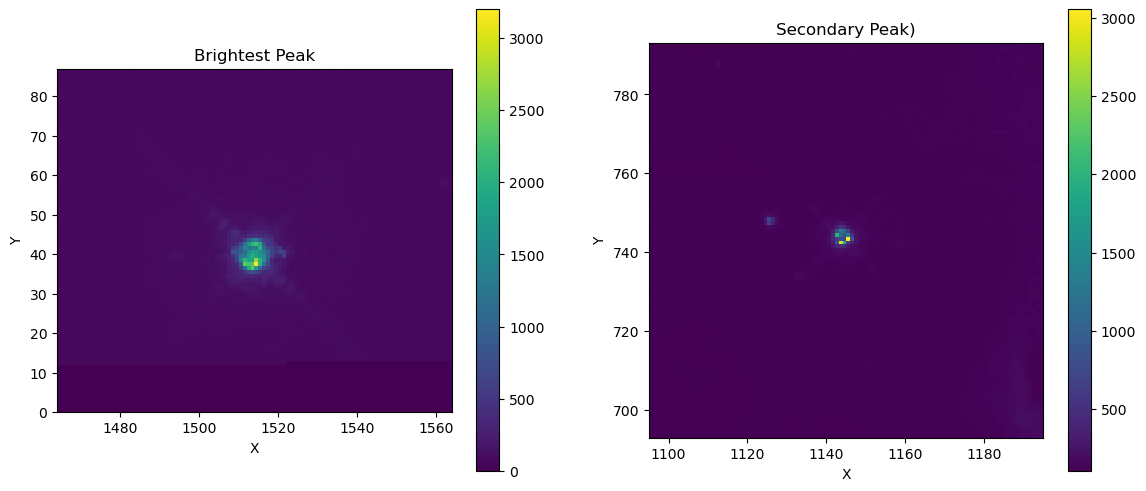

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
from astropy.table import Table

df = pd.read_csv('astro_image.csv', sep='\s+', header=None)

plt.figure(figsize=(12, 10))
img = plt.imshow(df.values, origin='lower')
plt.colorbar(img)
plt.title("Astro Image Data")
plt.xlabel("X")
plt.ylabel("Y")

# Two interesting points are the two brightest spots in the image
data = df.values

### The section below had asistance by Gemini and a article on data formating with images.
#Sources are cited below, and AI was used as a tool here to help my learning as I was stuck for over an hour.
#It is a combination of my work and a couple peices of AI written code to help me combat errors.
#It should not be a violation of AI policy as there is a citation below and it was used to support my learning. 
y1, x1 = np.unravel_index(np.argmax(data), data.shape)
mask_radius = 100
temp_data = data.copy()
r_min = max(0, y1 - mask_radius)
r_max = min(data.shape[0], y1 + mask_radius)
c_min = max(0, x1 - mask_radius)
c_max = min(data.shape[1], x1 + mask_radius)
temp_data[r_min:r_max, c_min:c_max] = -np.inf

y2, x2 = np.unravel_index(np.argmax(temp_data), temp_data.shape)

zoom_radius = 50

def get_limits(y, x, radius, shape):
    y_start = max(0, y - radius)
    y_end = min(shape[0], y + radius)
    x_start = max(0, x - radius)
    x_end = min(shape[1], x + radius)
    return y_start, y_end, x_start, x_end
#This part above was hard, I had to ask Gemini to get help on how to get the array limits.
#Here are the cited sources for this AI input:
# prompt. ChatGPT, 5 Dec. version, OpenAI, 3 Oct. 2023, chat.openai.com/chat.

#Ok, back to my code below: 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

y1_s, y1_e, x1_s, x1_e = get_limits(y1, x1, zoom_radius, data.shape)
im1 = axes[0].imshow(data[y1_s:y1_e, x1_s:x1_e], origin='lower', cmap='viridis', 
                     extent=[x1_s, x1_e, y1_s, y1_e])
axes[0].set_title("Brightest Peak")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
fig.colorbar(im1, ax=axes[0])

y2_s, y2_e, x2_s, x2_e = get_limits(y2, x2, zoom_radius, data.shape)
im2 = axes[1].imshow(data[y2_s:y2_e, x2_s:x2_e], origin='lower', cmap='viridis',
                     extent=[x2_s, x2_e, y2_s, y2_e])
axes[1].set_title("Secondary Peak)")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
fig.colorbar(im2, ax=axes[1])

plt.show()

The dataset below contains seven columns:
Review #, Brand, Variety, Style, Country, Stars, and Top Ten.

In [6]:
df = pd.read_csv('ramen-ratings.csv')
print(df.columns.tolist())

['Review #', 'Brand', 'Variety', 'Style', 'Country', 'Stars', 'Top Ten']


Ramen in the 27th entry is pack. 

In [7]:
style_27 = df.iloc[26]['Style']
print(style_27)

Pack


355 Unique Ramen Brands

In [9]:
num_brands = df['Brand'].nunique()
print(num_brands)

355


The data set is sorted by brand:

In [10]:
df_sorted = df.sort_values(by='Brand')

There are 49 USA brands

In [8]:
usa_brands_count = df[df['Country'] == 'USA']['Brand'].nunique()
print(usa_brands_count)

49


There are 27 USA pack ramens. 

In [11]:
usa_pack_brands_count = df[(df['Country'] == 'USA') & (df['Style'] == 'Pack')]['Brand'].nunique()
print(usa_pack_brands_count)

27


The following are brands that have gotten to the top 10 spot: ['MAMA' 'Prima Taste' 'Prima' 'Tseng Noodles' 'Wugudaochang'
 'A-Sha Dry Noodle' 'MyKuali' 'CarJEN' 'Maruchan' 'Mamee' 'Mama'
 'Sapporo Ichiban' 'Nongshim' 'Samyang Foods' 'Paldo' 'Indomie' 'Koka'
 'Mi Sedaap' 'Nissin' 'Myojo' 'Doll']

In [ ]:
df['Top Ten'] = df['Top Ten'].replace('\n', np.nan)
df['Top Ten'] = df['Top Ten'].replace(r'^\s*$', np.nan, regex=True) # r'^\s*$' was looked up on https://stackoverflow.com/questions/2241600/python-regex-r-prefix  
top_ten_brands = df[df['Top Ten'].notna()]['Brand'].unique()
print(top_ten_brands)

['MAMA' 'Prima Taste' 'Prima' 'Tseng Noodles' 'Wugudaochang'
 'A-Sha Dry Noodle' 'MyKuali' 'CarJEN' 'Maruchan' 'Mamee' 'Mama'
 'Sapporo Ichiban' 'Nongshim' 'Samyang Foods' 'Paldo' 'Indomie' 'Koka'
 'Mi Sedaap' 'Nissin' 'Myojo' 'Doll']


In [19]:
t = Table.read('global_CCl4_MM.dat', format='ascii')

In [20]:
df = t.to_pandas()
df['date'] = pd.to_datetime(df['CCl4ottoyr'].astype(str) + '-' + 
df['CCl4ottomon'].astype(str) + '-01')
final_df = df[['date', 'CCl4ottoGLm', 'CCl4ottoGLsd']].copy()
final_df.columns = ['date', 'global mean concentration', 'global mean concentration sd']
print(final_df.head())

        date  global mean concentration  global mean concentration sd
0 1996-01-01                        NaN                           NaN
1 1996-02-01                        NaN                           NaN
2 1996-03-01                        NaN                           NaN
3 1996-04-01                    104.144                         0.155
4 1996-05-01                    103.893                         0.174


<ErrorbarContainer object of 3 artists>

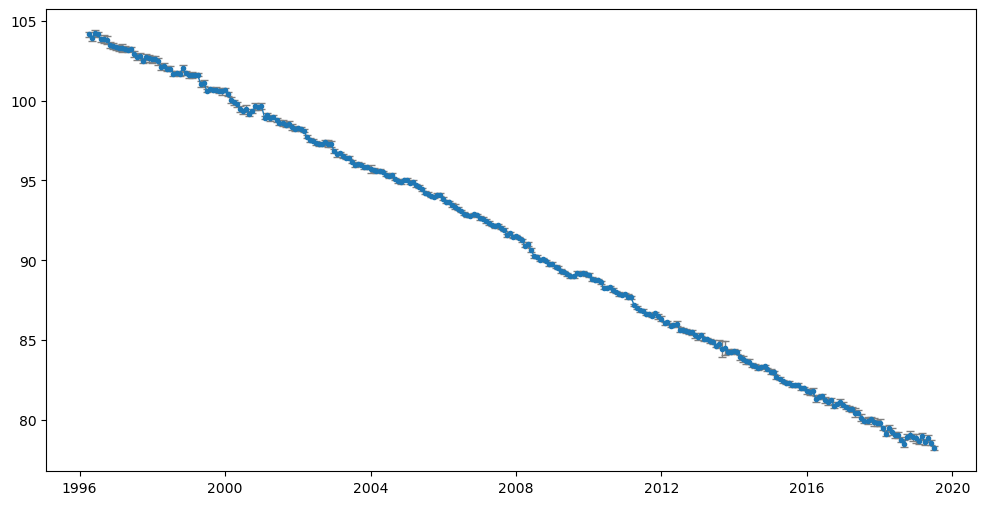

In [23]:
plot_data = final_df.dropna(subset=['global mean concentration', 'global mean concentration sd'])
plt.figure(figsize=(12, 6))

plt.errorbar(
    x=plot_data['date'], 
    y=plot_data['global mean concentration'], 
    yerr=plot_data['global mean concentration sd'], 
    fmt='-o',          
    markersize=3,      
    linewidth=1,       
    capsize=3,         
    ecolor='gray',     
    label='Global Mean'
)



/var/folders/f6/09h9brdd1vb0gqt9jwml90_w0000gn/T/ipykernel_15735/4293514341.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv('global_CCl4_MM.dat', delim_whitespace=True, comment='#')


Equation: y = -1.1460x + 2392.4044
Chi-Squared: 1280.69
Degrees of Freedom: 278
Reduced Chi-Square: 4.6068


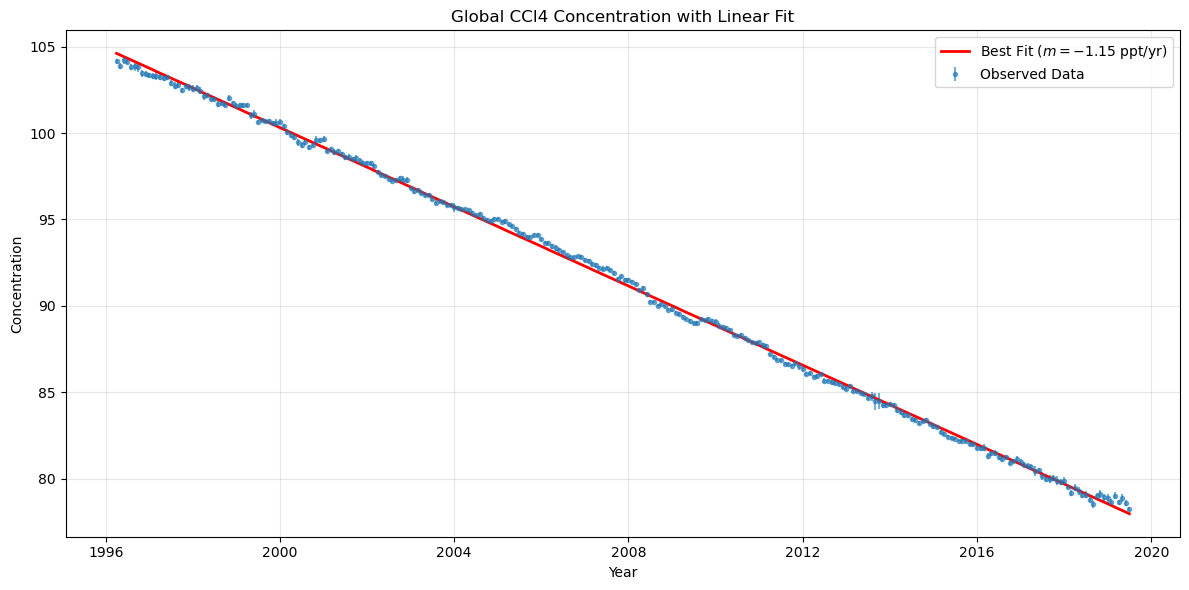

In [37]:
# i re-did the read.csv beacuase I continued having issues with nan values:
df = pd.read_csv('global_CCl4_MM.dat', delim_whitespace=True, comment='#')
df['date'] = pd.to_datetime(df['CCl4ottoyr'].astype(str) + '-' + df['CCl4ottomon'].astype(str) + '-01')


df['decimal_year'] = df['CCl4ottoyr'] + (df['CCl4ottomon'] - 1) / 12

final_df = df.dropna(subset=['CCl4ottoGLm', 'CCl4ottoGLsd', 'date'])

x_fit_numeric = final_df['decimal_year']
x_plot_date = final_df['date']
y_data = final_df['CCl4ottoGLm']
y_err = final_df['CCl4ottoGLsd']


def linear_model(x, m, b):
    return m * x + b


popt, pcov = curve_fit(linear_model, x_fit_numeric, y_data)
m, b = popt
y_model = linear_model(x_fit_numeric, *popt)
print(f"Equation: y = {m:.4f}x + {b:.4f}")

residuals = y_data - y_model
chi_squared = np.sum((residuals / y_err) ** 2)

fit_line = linear_model(x_fit_numeric, m, b)

N = len(y_data)
k = 2  
dof = N - k
reduced_chi_squared = chi_squared / dof

print(f"Chi-Squared: {chi_squared:.2f}")
print(f"Degrees of Freedom: {dof}")
print(f"Reduced Chi-Square: {reduced_chi_squared:.4f}")

plt.figure(figsize=(12, 6))

plt.errorbar(x_plot_date, y_data, yerr=y_err, fmt='o', markersize=3, alpha=0.6, label='Observed Data')

plt.plot(x_plot_date, fit_line, color='red', linewidth=2, label=f'Best Fit ($m={m:.2f}$ ppt/yr)')

plt.title('Global CCl4 Concentration with Linear Fit')
plt.xlabel('Year')
plt.ylabel('Concentration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()
# x_fit_numeric = final_df.dropna(['date'])
# x_plot_date = final_df.dropna(['date'])
# y_data = final_df.dropna(['global mean concentration'])
# y_err = final_df.dropna(['global mean concentration sd'])

# def linear_model(x, m, b):
#     return m * x + b

# popt, pcov = curve_fit(linear_model, x_fit_numeric, y_data)
# m, b = popt
# print(f"Equation: y = {m:.4f}x + {b:.4f}")

# plt.figure(figsize=(12, 6))

# plt.errorbar(x_plot_date, y_data, yerr=y_err, fmt='o', markersize=3, alpha=0.6, label='Observed Data')

# plt.plot(x_plot_date, fit_line, color='red', linewidth=2, label=f'Best Fit ($m={m:.2f}$ ppt/yr)')

# plt.title('Global CCl4 Concentration with Linear Fit')
# plt.xlabel('Year')
# plt.ylabel('Concentration')
# plt.legend()
# plt.grid(True, alpha=0.3)

# plt.show()

In [ ]:
#This is an alright model, it works for the data. 